# 01 · Customer Lifetime Value (noncontractual, weekly)

In non-subscription retail, customers come and go with no contract. CLV needs two estimates:

1. **Engagement** — will they return? (BG/NBD)
2. **Spend** — how much per purchase? (Gamma-Gamma)

This notebook runs **every step** of that BTYD pipeline (same story as the [Databricks CLV accelerator](https://github.com/databricks-industry-solutions/customer-lifetime-value) / `DATABRICKS_CLV_PLAN.md`), on this repo’s weekly Hardie-faithful protocol.

| Step | Section | What you do |
|------|---------|-------------|
| 1 | Access data | Load audit order spine |
| 2 | Explore | Confirm skewed frequency & spend |
| 3 | Protocol | Fit / val / test cutoffs |
| 4 | RFM metrics | Build calibration + holdout summaries |
| 5 | BG/NBD (val) | Fit engagement; predict val purchases |
| 6 | Gamma-Gamma (val) | Fit spend; form val CLV → **£ scale** |
| 7 | BG/NBD (test) | Refit on test calibration; score + diagnose |
| 8 | Gamma-Gamma (test) | Refit spend on test calibration |
| 9 | CLV + gate | Scale, accept/reject, ranking, MLP foil |
| 10 | Segments | Value × activity action map |
| 11 | Scenarios | Illustrative what-ifs |
| 12 | Artifacts | Persist only if gate passes |

**CLV formula:** `E[purchases] × E[avg spend] × val_scale` (no monthly discounting here).  
**Purchase model:** stationary weekly BG/NBD (Hardie default — no seasonal overlay).  
**Upstream:** `00-customer-base-audit.ipynb`.


In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lifetimes.plotting import plot_calibration_purchases_vs_holdout_purchases

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def find_project_root() -> Path:
    path = Path.cwd().resolve()
    for candidate in (path, *path.parents):
        if (candidate / "scripts" / "uci_pipeline.py").exists():
            return candidate
    return path


PROJECT_ROOT = find_project_root()
DATA = PROJECT_ROOT / "data" / "modeling"
MODELS = PROJECT_ROOT / "models"
MODELS.mkdir(exist_ok=True)

import sys
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
from clv_weekly import (
    AGG_ERROR_MAX,
    FIT_FRAC,
    FREQ,
    HORIZON_WEEKS_CANDIDATES,
    VAL_FRAC,
    assert_accepted,
    assign_segments,
    audit_no_leakage,
    build_summary,
    cumulative_expected_purchases,
    fit_purchase_model,
    fit_score_monetary,
    score_purchases,
    split_dates,
    weeks_between,
)


def save_artifact(name: str, obj) -> Path:
    path = MODELS / name
    joblib.dump(obj, path)
    print(f"Saved → {path.relative_to(PROJECT_ROOT)}")
    return path


print(
    f"Setup complete · FREQ={FREQ} · stepwise BG/NBD + Gamma-Gamma · "
    f"fit/val/test={FIT_FRAC:.0%}/{VAL_FRAC:.0%}/{1 - FIT_FRAC - VAL_FRAC:.0%} · "
    f"£ gate ≤ {AGG_ERROR_MAX:.0%}"
)


Setup complete · FREQ=W · stepwise BG/NBD + Gamma-Gamma · fit/val/test=45%/20%/35% · £ gate ≤ 5%


## 1 · Access the data

Order-level spine from the customer-base audit (UCI Online Retail II). Grain = **one row per order** with `spend` (Databricks collapses lines to daily spend; we stay at order / week).


In [2]:
from customer_base_audit import attach_acquisition, build_orders, load_fact_transactions

audit_orders = DATA / "audit" / "uci_orders.parquet"
if audit_orders.exists():
    orders = pd.read_parquet(audit_orders)
    orders["order_date"] = pd.to_datetime(orders["order_date"])
    print("Loaded", audit_orders.relative_to(PROJECT_ROOT))
else:
    fact = load_fact_transactions(DATA / "uci_fact_transactions.parquet")
    orders = attach_acquisition(build_orders(fact))

print(f"Orders: {len(orders):,} · Customers: {orders['customer_id'].nunique():,}")
print(f"Span: {orders['order_date'].min().date()} → {orders['order_date'].max().date()}")
print(f"Columns: {list(orders.columns)}")
display(orders.head(10))


Loaded data\modeling\audit\uci_orders.parquet
Orders: 36,684 · Customers: 5,798
Span: 2009-12-01 → 2011-12-09
Columns: ['customer_id', 'order_id', 'order_date', 'spend', 'n_lines', 'acquisition_date', 'cohort_id']


,customer_id,order_id,order_date,spend,n_lines,acquisition_date,cohort_id
0,12346,491725,2009-12-14 08:34:00,45.00,1,2009-12-14 08:34:00,2009Q4
1,12346,491742,2009-12-14 11:00:00,22.50,1,2009-12-14 08:34:00,2009Q4
2,12346,491744,2009-12-14 11:02:00,22.50,1,2009-12-14 08:34:00,2009Q4
3,12346,492718,2009-12-18 10:47:00,22.50,1,2009-12-14 08:34:00,2009Q4
4,12346,492722,2009-12-18 10:55:00,1.00,1,2009-12-14 08:34:00,2009Q4
5,12346,493410,2010-01-04 09:24:00,22.50,1,2009-12-14 08:34:00,2009Q4
6,12346,493412,2010-01-04 09:53:00,22.50,1,2009-12-14 08:34:00,2009Q4
7,12346,494450,2010-01-14 13:50:00,22.50,1,2009-12-14 08:34:00,2009Q4
8,12346,495295,2010-01-22 13:30:00,22.50,1,2009-12-14 08:34:00,2009Q4
9,12346,499763,2010-03-02 13:08:00,27.05,5,2009-12-14 08:34:00,2009Q4


## 2 · Explore purchase behavior

BTYD assumes frequency and spend are **right-skewed**, not Gaussian. If that holds, average lifetime × average spend misstates equity; individual RFM does not.


Customers: 5,798 · one-timers: 1,592 (27.5%)
Orders/customer — median 3 · mean 6.33 · p95 21
Order spend £ — median 305.00 · mean 474.22 · p95 1239.97


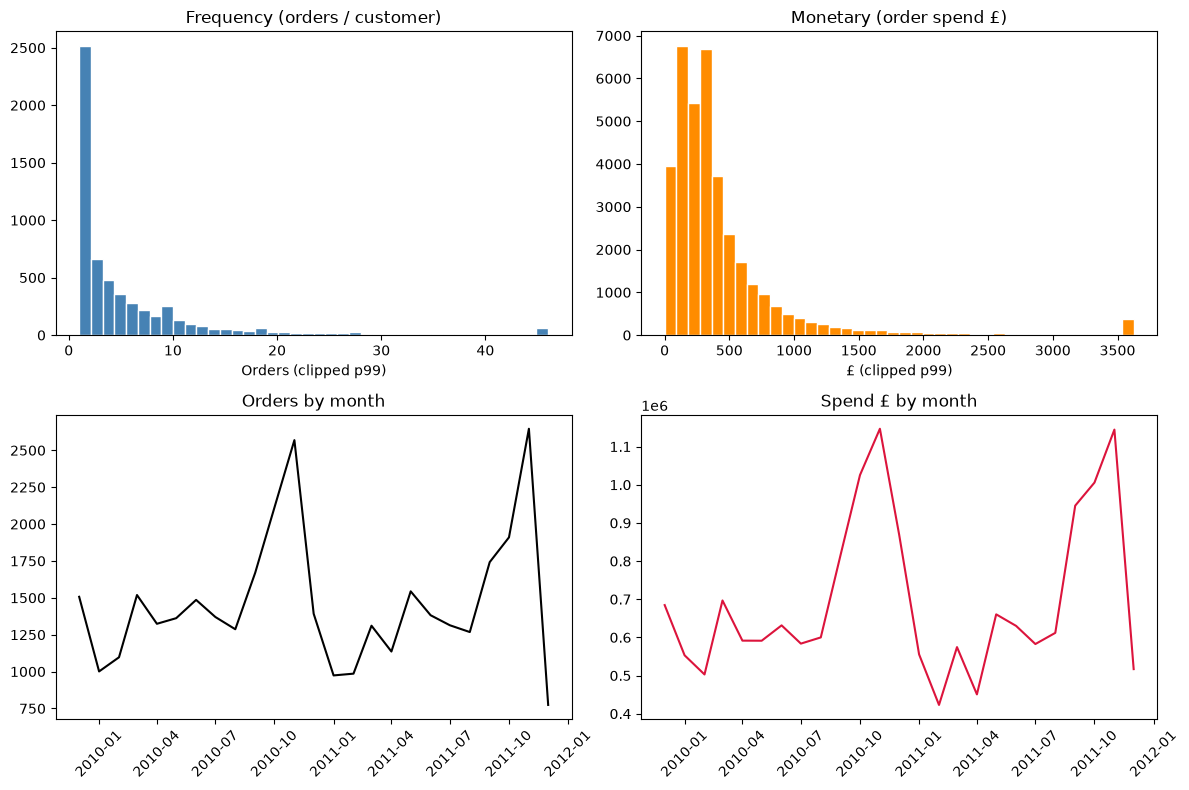

,month,orders,spend,customers
17,2011-05-01,1544,660462.0,1047
18,2011-06-01,1382,630187.0,983
19,2011-07-01,1314,582648.0,938
20,2011-08-01,1268,611917.0,924
21,2011-09-01,1742,945283.0,1256
22,2011-10-01,1910,1005784.0,1353
23,2011-11-01,2646,1144600.0,1657
24,2011-12-01,774,516902.0,611


In [3]:
txn_per_cust = orders.groupby("customer_id")["order_id"].nunique()
spend = orders["spend"]
one_timers = int((txn_per_cust == 1).sum())
print(
    f"Customers: {txn_per_cust.size:,} · one-timers: {one_timers:,} "
    f"({one_timers / txn_per_cust.size:.1%})"
)
print(
    f"Orders/customer — median {txn_per_cust.median():.0f} · "
    f"mean {txn_per_cust.mean():.2f} · p95 {txn_per_cust.quantile(0.95):.0f}"
)
print(
    f"Order spend £ — median {spend.median():.2f} · "
    f"mean {spend.mean():.2f} · p95 {spend.quantile(0.95):.2f}"
)

# Monthly activity (seasonality is visible in actuals; not in the purchase model)
monthly = (
    orders.assign(month=orders["order_date"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .agg(orders=("order_id", "nunique"), spend=("spend", "sum"), customers=("customer_id", "nunique"))
    .reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes[0, 0].hist(txn_per_cust.clip(upper=txn_per_cust.quantile(0.99)), bins=40, color="steelblue", edgecolor="white")
axes[0, 0].set_title("Frequency (orders / customer)")
axes[0, 0].set_xlabel("Orders (clipped p99)")
axes[0, 1].hist(spend.clip(upper=spend.quantile(0.99)), bins=40, color="darkorange", edgecolor="white")
axes[0, 1].set_title("Monetary (order spend £)")
axes[0, 1].set_xlabel("£ (clipped p99)")
axes[1, 0].plot(monthly["month"], monthly["orders"], color="black")
axes[1, 0].set_title("Orders by month")
axes[1, 0].tick_params(axis="x", rotation=45)
axes[1, 1].plot(monthly["month"], monthly["spend"], color="crimson")
axes[1, 1].set_title("Spend £ by month")
axes[1, 1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()
display(monthly.tail(8).round(0))


#### Assessment — explore

Frequency and spend are long-tailed → BG/NBD + Gamma-Gamma are appropriate. Monthly plots show seasonal peaks in **actuals**; the purchase model stays stationary on purpose (equity baseline, not a demand plan).


## 3 · Define the protocol (fit / validation / test)

Databricks uses a single calibration + ~90-day holdout. This repo uses a **three-way** split so £ scale never sees test labels:

| Window | Share | Role |
|--------|-------|------|
| Fit → `fit_end` | 45% | Contained in calibration for later models |
| → `val_end` | +20% | Holdout for **£ scale only** |
| → `obs_end` | +35% | Unseen **test** for the ≤5% gate |


In [4]:
min_d, fit_end, val_end, max_d = split_dates(orders)
hw_val = weeks_between(fit_end, val_end)
hw_test = weeks_between(val_end, max_d)

print(f"FREQ = {FREQ} (weeks)")
print(f"min_d    = {min_d.date()}")
print(f"fit_end  = {fit_end.date()}  (end of fit calendar share)")
print(f"val_end  = {val_end.date()}  (calibration end for TEST score set)")
print(f"obs_end  = {max_d.date()}  (end of data)")
print(f"Val holdout horizon  = {hw_val} weeks")
print(f"Test holdout horizon = {hw_test} weeks")


FREQ = W (weeks)
min_d    = 2009-12-01
fit_end  = 2010-10-29  (end of fit calendar share)
val_end  = 2011-03-25  (calibration end for TEST score set)
obs_end  = 2011-12-09  (end of data)
Val holdout horizon  = 21 weeks
Test holdout horizon = 37 weeks


## 4 · Calculate customer metrics (RFM)

Per-customer inputs (time unit = **weeks**):

| Metric | Meaning |
|--------|---------|
| `frequency_cal` | Repeat purchase periods after first purchase (in calibration) |
| `recency_cal` | Customer age (weeks) at last calibration purchase |
| `T_cal` | Age from first purchase to end of calibration |
| `monetary_value_cal` | Average spend on repeat calibration periods |
| `frequency_holdout` / revenue | Actuals in the holdout window (for validation only) |

Build **two** summaries: validation window (for scale) and test window (for shipping scores).


In [5]:
# --- Validation RFM: calibrate through fit_end, hold out fit_end → val_end ---
s_val = build_summary(orders, fit_end, val_end)
print("=== Validation summary ===")
print(f"Customers: {len(s_val):,} · repeat in cal: {(s_val['frequency_cal'] > 0).mean():.1%}")
print(f"duration_holdout (weeks): {int(s_val['duration_holdout'].iloc[0])}")
display(s_val.head(10))
display(s_val[["frequency_cal", "recency_cal", "T_cal", "monetary_value_cal", "frequency_holdout", "actual_holdout_revenue"]].describe().round(2))


=== Validation summary ===
Customers: 3,874 · repeat in cal: 61.6%
duration_holdout (weeks): 21


,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout,actual_holdout_revenue,actual_holdout_orders
customer_id,,,,,,,,,
12346,5.0,28.0,45.0,51.872,1.0,77183.600000,21.0,77183.60,1.0
12348,0.0,0.0,4.0,0.000,2.0,560.120000,21.0,1120.24,2.0
12349,2.0,26.0,26.0,801.310,0.0,0.000000,21.0,0.00,0.0
12356,0.0,0.0,2.0,0.000,3.0,1641.143333,21.0,4923.43,3.0
12358,1.0,26.0,46.0,268.100,1.0,1021.080000,21.0,1021.08,1.0
12359,5.0,44.0,47.0,360.534,2.0,1193.205000,21.0,2386.41,2.0
12360,2.0,13.0,35.0,331.020,2.0,405.395000,21.0,810.79,2.0
12361,2.0,31.0,39.0,106.075,1.0,189.900000,21.0,189.90,1.0
12362,0.0,0.0,47.0,0.000,1.0,479.100000,21.0,479.10,1.0


,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,actual_holdout_revenue
count,3874.00,3874.00,3874.00,3874.00,3874.00,3874.00
mean,2.38,16.39,28.94,271.20,1.29,788.01
std,4.09,16.60,15.01,504.00,2.10,3391.84
min,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,18.00,0.00,0.00,0.00
50%,1.00,13.00,32.00,174.52,1.00,109.40
75%,3.00,32.00,42.00,365.35,2.00,640.82
max,44.00,47.00,47.00,11221.87,20.00,91060.36


=== Test summary (score set) ===
Customers: 4,622 · repeat in cal: 65.1%
duration_holdout (weeks): 37


,frequency_cal,recency_cal,T_cal,monetary_value_cal,frequency_holdout,monetary_value_holdout,duration_holdout,actual_holdout_revenue,actual_holdout_orders
customer_id,,,,,,,,,
12346,6.0,57.0,66.0,12907.160000,0.0,0.000000,37.0,0.00,0.0
12348,2.0,17.0,25.0,560.120000,2.0,338.500000,37.0,677.00,2.0
12349,2.0,26.0,47.0,801.310000,1.0,1757.550000,37.0,1757.55,1.0
12350,0.0,0.0,7.0,0.000000,0.0,0.000000,37.0,0.00,0.0
12352,5.0,19.0,19.0,352.372000,3.0,314.743333,37.0,944.23,3.0
12356,3.0,14.0,23.0,1641.143333,2.0,269.905000,37.0,539.81,2.0
12357,0.0,0.0,18.0,0.000000,1.0,6207.670000,37.0,6207.67,1.0
12358,2.0,51.0,67.0,644.590000,2.0,584.030000,37.0,1168.06,2.0
12359,7.0,62.0,68.0,598.440000,2.0,1993.085000,37.0,3986.17,2.0


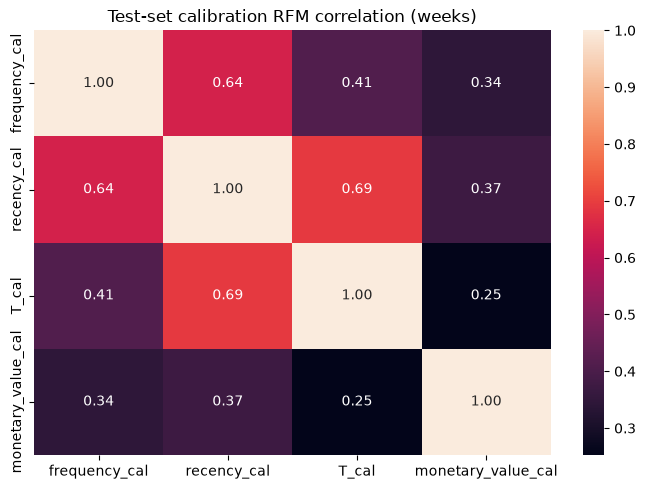

In [6]:
# --- Test RFM: calibrate through val_end, hold out val_end → obs_end ---
s_test = build_summary(orders, val_end, max_d)
print("=== Test summary (score set) ===")
print(f"Customers: {len(s_test):,} · repeat in cal: {(s_test['frequency_cal'] > 0).mean():.1%}")
print(f"duration_holdout (weeks): {int(s_test['duration_holdout'].iloc[0])}")
display(s_test.head(10))

cal_cols = ["frequency_cal", "recency_cal", "T_cal", "monetary_value_cal"]
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(s_test[cal_cols].corr(), annot=True, fmt=".2f", ax=ax)
ax.set_title("Test-set calibration RFM correlation (weeks)")
plt.tight_layout()
plt.show()


#### Assessment — RFM

Same metrics Databricks builds with `summary_data_from_transaction_data` / Spark — here via `lifetimes` weekly `calibration_and_holdout_data`. Test scores only use customers known by `val_end` (no future-acquisition leakage).


## 5 · Train engagement on the validation window (BG/NBD)

Fit BG/NBD on **validation calibration** RFM, predict purchases over the val holdout, then (next section) attach spend and form the **val-only £ scale**.

Paper: [Fader, Hardie & Lee 2005](http://brucehardie.com/papers/018/fader_et_al_mksc_05.pdf).


BG/NBD (val) params: {'r': 0.9788, 'alpha': 12.8113, 'a': 0.0, 'b': 38898278.4115}
Val purchases: pred 6,206 vs actual 5,956


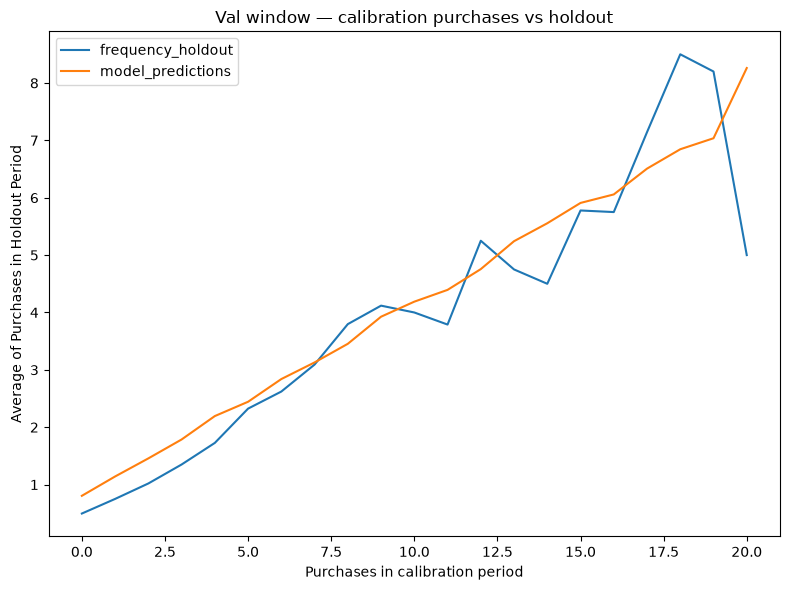

,frequency_cal,recency_cal,T_cal,p_alive,expected_purchases,frequency_holdout
customer_id,,,,,,
12346,5.0,28.0,45.0,1.0,2.170073,1.0
12348,0.0,0.0,4.0,1.0,1.218156,2.0
12349,2.0,26.0,26.0,1.0,1.609353,0.0
12356,0.0,0.0,2.0,1.0,1.382855,3.0
12358,1.0,26.0,46.0,1.0,0.704872,1.0
12359,5.0,44.0,47.0,1.0,2.097501,2.0
12360,2.0,13.0,35.0,1.0,1.306335,2.0
12361,2.0,31.0,39.0,1.0,1.205457,1.0
12362,0.0,0.0,47.0,1.0,0.341979,1.0


In [7]:
bgf_val = fit_purchase_model(s_val)
s_val = score_purchases(s_val, bgf_val, horizon_weeks=hw_val)

print("BG/NBD (val) params:", {k: round(float(v), 4) for k, v in bgf_val.params_.items()})
print(
    f"Val purchases: pred {s_val['expected_purchases'].sum():,.0f} vs "
    f"actual {s_val['actual_holdout_orders'].sum():,.0f}"
)

# Lifetimes calibration vs holdout chart (Databricks-style)
plot_calibration_purchases_vs_holdout_purchases(
    bgf_val,
    s_val.rename(columns={"frequency_holdout": "frequency_holdout"}),
    n=hw_val,
    **{"figsize": (8, 6)},
)
plt.title("Val window — calibration purchases vs holdout")
plt.tight_layout()
plt.show()

display(s_val[["frequency_cal", "recency_cal", "T_cal", "p_alive", "expected_purchases", "frequency_holdout"]].head(10))


#### Assessment — BG/NBD (val)

Higher calibration frequency should map to higher holdout purchases. This fit is used only to form validation CLV for scaling — the **shipped** engagement model is refit on the test calibration in §7.


## 6 · Train spend on the validation window (Gamma-Gamma) → £ scale

Gamma-Gamma supplies expected average order value ([Fader & Hardie 2013](http://www.brucehardie.com/notes/025/gamma_gamma.pdf)). Assumption: frequency ⊥ monetary value.

```text
val_raw_CLV = E[purchases]_val × E[spend]_val
val_scale   = val_actual_£ / val_raw_CLV
```

Test labels never enter this scale.


In [8]:
s_val, ggf_val, mon_cap_val = fit_score_monetary(s_val)
val_actual = float(s_val["actual_holdout_revenue"].sum())
val_pred = float(s_val["expected_clv"].sum())
if val_pred <= 0 or val_actual <= 0:
    raise RuntimeError("Validation window has zero predicted or actual revenue")
scale = val_actual / val_pred

gg_corr_val = float(
    s_val.loc[s_val["frequency_cal"] > 0, ["frequency_cal", "monetary_value_cal"]]
    .corr()
    .iloc[0, 1]
)
print("GG (val) params:", {k: round(float(v), 4) for k, v in ggf_val.params_.items()})
print(f"GG independence (freq vs monetary): {gg_corr_val:.3f}")
print(f"Monetary winsor cap (val cal p99): £{mon_cap_val:,.2f}")
print(f"Val £ actual={val_actual:,.0f} · pred={val_pred:,.0f} · scale={scale:.4f}")
display(s_val[["expected_purchases", "expected_avg_spend", "expected_clv", "actual_holdout_revenue"]].head(10))


GG (val) params: {'p': 3.7678, 'q': 0.3294, 'v': 3.6484}
GG independence (freq vs monetary): 0.217
Monetary winsor cap (val cal p99): £2,128.85
Val £ actual=3,052,749 · pred=2,880,764 · scale=1.0597


,expected_purchases,expected_avg_spend,expected_clv,actual_holdout_revenue
customer_id,,,,
12346,2.170073,54.543086,118.362487,77183.60
12348,1.218156,318.986667,388.575571,1120.24
12349,1.609353,881.581777,1418.775901,0.00
12356,1.382855,318.986667,441.112404,4923.43
12358,0.704872,330.582113,233.018115,1021.08
12359,2.097501,374.597092,785.717832,2386.41
12360,1.306335,365.355354,477.276323,810.79
12361,1.205457,118.438446,142.772484,189.90
12362,0.341979,318.986667,109.086666,479.10


#### Assessment — Gamma-Gamma (val) + scale

Weak freq–monetary correlation supports GG. A scale near 1.0 means raw purchase × spend already matched val £ closely; the scale only recalibrates levels before the test gate.


## 7 · Train engagement on the test score set (BG/NBD)

Refit BG/NBD with calibration through `val_end`. Score `p_alive` and expected purchases over the **test** horizon. Then diagnose: conditional expectations, alive / frequency–recency matrices, aggregate tracking.


In [9]:
bgf = fit_purchase_model(s_test)
s_test = score_purchases(s_test, bgf, horizon_weeks=hw_test)

print("BG/NBD (test) params:", {k: round(float(v), 4) for k, v in bgf.params_.items()})
print(
    f"TEST purchases: pred {s_test['expected_purchases'].sum():,.0f} vs "
    f"actual {s_test['actual_holdout_orders'].sum():,.0f}"
)
print(
    f"p_alive median={s_test['p_alive'].median():.3f} · "
    f"mean E[purchases]={s_test['expected_purchases'].mean():.2f}"
)
display(s_test[["frequency_cal", "recency_cal", "T_cal", "p_alive", "expected_purchases", "frequency_holdout"]].head(10))


BG/NBD (test) params: {'r': 0.7934, 'alpha': 11.6733, 'a': 0.1297, 'b': 6.8385}
TEST purchases: pred 10,479 vs actual 11,261
p_alive median=0.981 · mean E[purchases]=2.27


,frequency_cal,recency_cal,T_cal,p_alive,expected_purchases,frequency_holdout
customer_id,,,,,,
12346,6.0,57.0,66.0,0.975333,3.103357,0.0
12348,2.0,17.0,25.0,0.968145,2.663904,2.0
12349,2.0,26.0,47.0,0.946039,1.640494,1.0
12350,0.0,0.0,7.0,1.000000,1.529821,0.0
12352,5.0,19.0,19.0,0.988175,6.659822,3.0
12356,3.0,14.0,23.0,0.956131,3.762569,2.0
12357,0.0,0.0,18.0,1.000000,0.971429,1.0
12358,2.0,51.0,67.0,0.969719,1.258770,2.0
12359,7.0,62.0,68.0,0.981744,3.492435,2.0


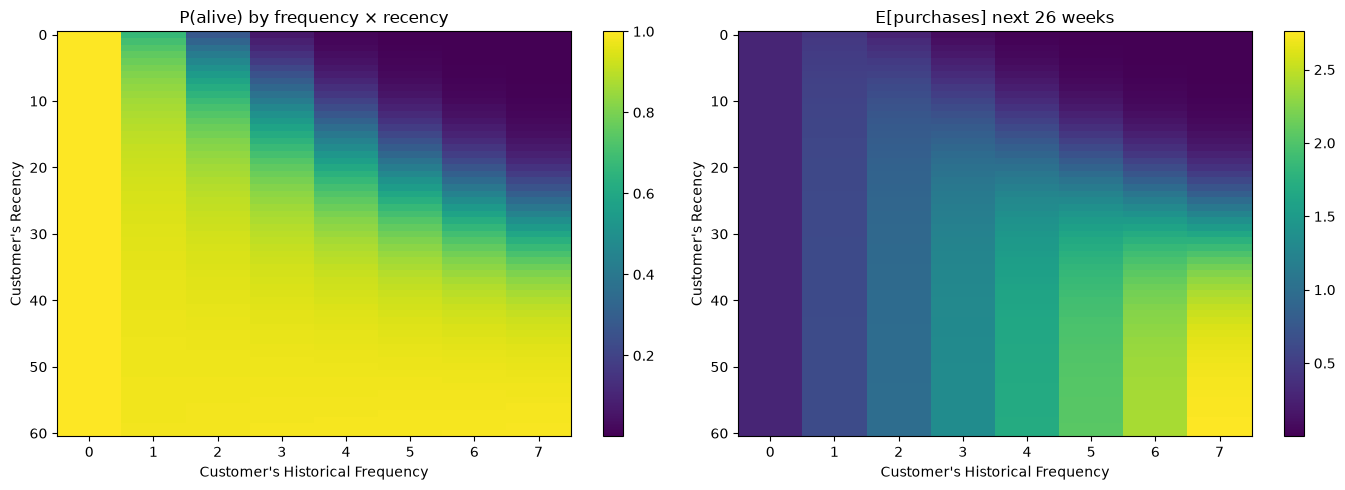

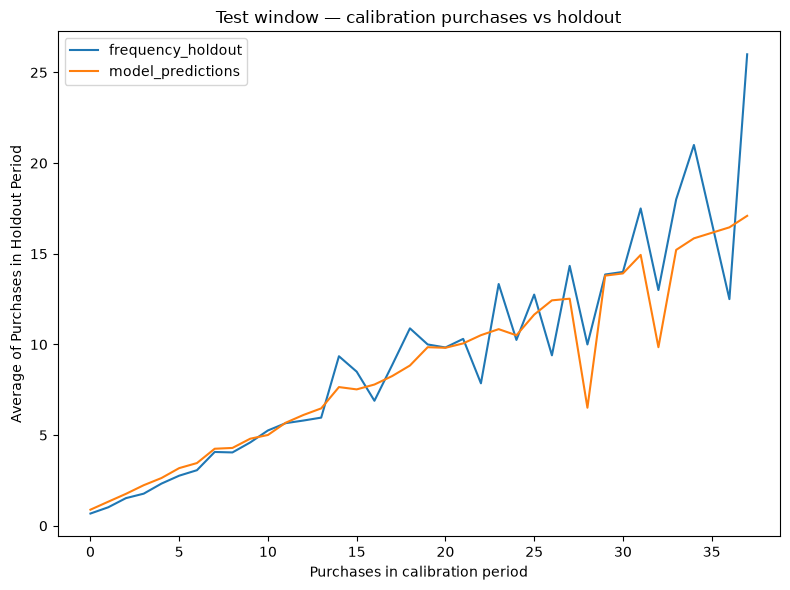

In [10]:
# Databricks-style matrices — lifetimes plot_* calls plt.subplot(111) and ignores plt.sca,
# so we draw heatmaps directly on our own axes.
max_freq = int(min(7, s_test["frequency_cal"].quantile(0.99)))
max_rec = int(min(60, s_test["T_cal"].quantile(0.99)))
T_plot = min(hw_test, 26)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

z_alive = bgf.conditional_probability_alive_matrix(max_frequency=max_freq, max_recency=max_rec)
pcm0 = axes[0].imshow(z_alive, interpolation="none", aspect="auto")
axes[0].set_xlabel("Customer's Historical Frequency")
axes[0].set_ylabel("Customer's Recency")
axes[0].set_title("P(alive) by frequency × recency")
fig.colorbar(pcm0, ax=axes[0])

Z = np.zeros((max_rec + 1, max_freq + 1))
for i, recency in enumerate(np.arange(max_rec + 1)):
    for j, frequency in enumerate(np.arange(max_freq + 1)):
        Z[i, j] = bgf.conditional_expected_number_of_purchases_up_to_time(
            T_plot, frequency, recency, max_rec
        )
pcm1 = axes[1].imshow(Z, interpolation="none", aspect="auto")
axes[1].set_xlabel("Customer's Historical Frequency")
axes[1].set_ylabel("Customer's Recency")
axes[1].set_title(f"E[purchases] next {T_plot} weeks")
fig.colorbar(pcm1, ax=axes[1])

plt.tight_layout()
plt.show()

plot_calibration_purchases_vs_holdout_purchases(bgf, s_test, n=hw_test, **{"figsize": (8, 6)})
plt.title("Test window — calibration purchases vs holdout")
plt.tight_layout()
plt.show()


#### Reading the calibration-vs-holdout chart

Each point is a **bucket of customers** with the same `frequency_cal` (x-axis: purchases in the calibration period). Blue = their actual mean holdout purchases; orange = BG/NBD's predicted mean for that same bucket.

**What this run shows:**

- **0–~13 calibration purchases** (the bulk of the customer base) — blue and orange track each other closely. The model is well calibrated where most customers live.
- **~14+ calibration purchases** — blue gets spiky while orange stays smooth. These are high-frequency buckets with **few customers each** (see the shrinking sample size as `x` grows), so one or two customers' actual holdout counts swing the bucket average a lot. BG/NBD instead reports the *expected* value, which is naturally smoother.
- **The last point (~37)** is the most extreme — likely a single very active customer. Don't read one sparse point as a systematic miss.

This is consistent with the other diagnostics: aggregate test purchase |error| ~7% and £ gate ~2.4% pass, and Spearman ~0.62 shows the model ranks customers correctly across the RFM ladder. **Tracking well for the bulk of the base, noisy-but-expected at the sparse high-frequency tail** — not evidence of a broken fit.


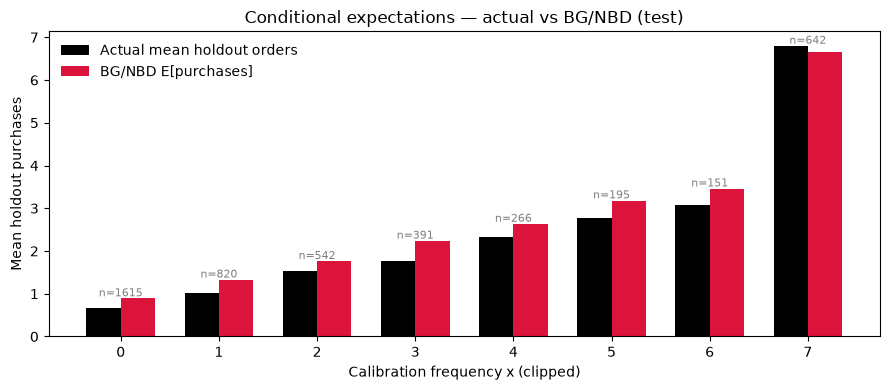

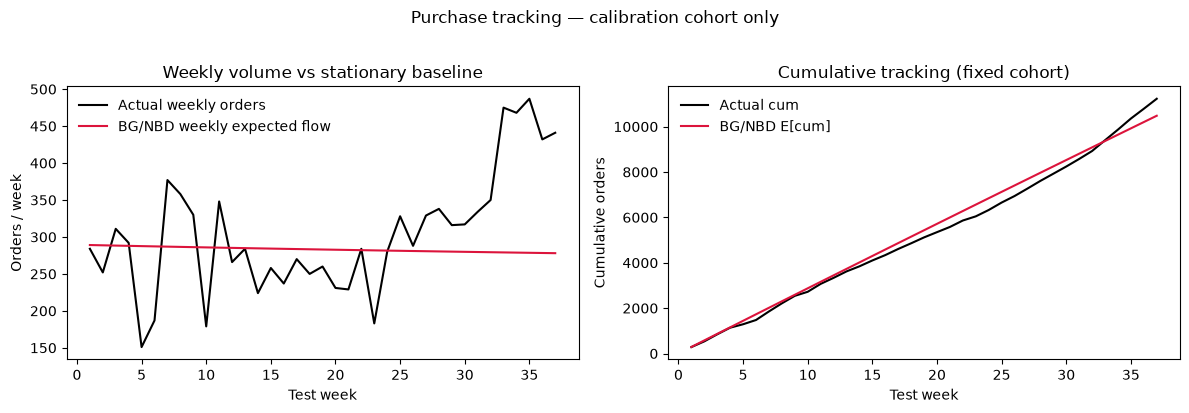

End-of-horizon (cal cohort): actual=11,228 · BG/NBD=10,479 · |gap|=6.7%
TEST purchase |error| (informational): 6.9%
Excluded from chart: 2,771 orders from 1,176 customers first seen after val_end.


In [11]:
# Conditional expectations by cal frequency
freq_cap = int(min(7, s_test["frequency_cal"].quantile(0.99)))
cond = s_test.copy()
cond["freq_bin"] = cond["frequency_cal"].clip(upper=freq_cap).astype(int)
by_x = (
    cond.groupby("freq_bin", as_index=False)
    .agg(
        n=("expected_purchases", "size"),
        actual_mean=("frequency_holdout", "mean"),
        pred_mean=("expected_purchases", "mean"),
    )
)
x = by_x["freq_bin"].to_numpy()
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w / 2, by_x["actual_mean"], width=w, color="black", label="Actual mean holdout orders")
ax.bar(x + w / 2, by_x["pred_mean"], width=w, color="crimson", label="BG/NBD E[purchases]")
ax.set_xlabel("Calibration frequency x (clipped)")
ax.set_ylabel("Mean holdout purchases")
ax.set_title("Conditional expectations — actual vs BG/NBD (test)")
ax.legend(frameon=False)
for _, row in by_x.iterrows():
    ax.text(
        row["freq_bin"],
        max(row["actual_mean"], row["pred_mean"]) + 0.05,
        f"n={int(row['n'])}",
        ha="center",
        fontsize=8,
        color="gray",
    )
plt.tight_layout()
plt.show()

# Aggregate tracking — fixed calibration cohort only
hold = orders[(orders["order_date"] > val_end) & (orders["order_date"] <= max_d)].copy()
cal_ids = s_test.index
hold_cohort = hold[hold["customer_id"].isin(cal_ids)].copy()
new_mask = ~hold["customer_id"].isin(cal_ids)
n_new_orders = int(hold.loc[new_mask, "order_id"].nunique())
n_new_cust = int(hold.loc[new_mask, "customer_id"].nunique())

hold_w = hold_cohort.copy()
hold_w["hold_week"] = ((hold_w["order_date"] - val_end).dt.days // 7) + 1
actual_by_week = hold_w.groupby("hold_week")["order_id"].nunique()
weeks = np.arange(1, hw_test + 1)
actual_weekly = actual_by_week.reindex(weeks).fillna(0).to_numpy(dtype=float)
actual_cum = np.cumsum(actual_weekly)
pred_cum = cumulative_expected_purchases(bgf, s_test, hw_test)
pred_weekly = np.diff(pred_cum, prepend=0.0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(weeks, actual_weekly, color="black", label="Actual weekly orders")
axes[0].plot(weeks, pred_weekly, color="crimson", label="BG/NBD weekly expected flow")
axes[0].set_xlabel("Test week")
axes[0].set_ylabel("Orders / week")
axes[0].set_title("Weekly volume vs stationary baseline")
axes[0].legend(frameon=False)
axes[1].plot(weeks, actual_cum, color="black", label="Actual cum")
axes[1].plot(weeks, pred_cum, color="crimson", label="BG/NBD E[cum]")
axes[1].set_xlabel("Test week")
axes[1].set_ylabel("Cumulative orders")
axes[1].set_title("Cumulative tracking (fixed cohort)")
axes[1].legend(frameon=False)
fig.suptitle("Purchase tracking — calibration cohort only", y=1.02)
plt.tight_layout()
plt.show()

gap = abs(actual_cum[-1] - pred_cum[-1]) / max(actual_cum[-1], 1)
test_orders_pred = float(s_test["expected_purchases"].sum())
test_orders_actual = float(s_test["actual_holdout_orders"].sum())
orders_agg_error = abs(test_orders_pred - test_orders_actual) / test_orders_actual
print(
    f"End-of-horizon (cal cohort): actual={actual_cum[-1]:,.0f} · "
    f"BG/NBD={pred_cum[-1]:,.0f} · |gap|={gap:.1%}"
)
print(f"TEST purchase |error| (informational): {orders_agg_error:.1%}")
print(
    f"Excluded from chart: {n_new_orders:,} orders from {n_new_cust:,} customers "
    f"first seen after val_end."
)


#### Assessment — engagement (test)

Alive and frequency–recency matrices show the classic BTYD pattern: recent + frequent ⇒ high P(alive) and expected purchases. Aggregate path is intentionally flat; seasonal peaks stay in actuals. Transaction |error| is diagnostic — **not** the commercial gate.


## 8 · Train spend on the test score set (Gamma-Gamma)

Refit Gamma-Gamma on test calibration monetary (winsorized at cal p99). Form **raw** CLV = purchases × expected avg spend; apply `val_scale` in the next section.


GG (test) params: {'p': 3.7695, 'q': 0.3301, 'v': 3.6619}
GG independence (freq vs monetary): 0.211
Monetary winsor cap (test cal p99): £2,266.25


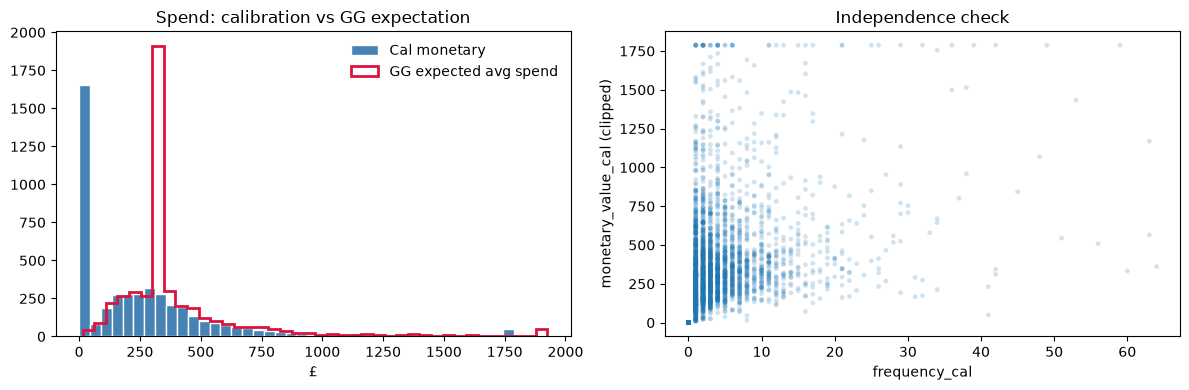

,expected_purchases,expected_avg_spend,expected_clv,actual_holdout_revenue
customer_id,,,,
12346,3.103357,2336.049267,7249.594358,0.00
12348,2.663904,616.755461,1642.977179,677.00
12349,1.640494,881.467626,1446.042139,1757.55
12350,1.529821,318.505000,487.255490,0.00
12352,6.659822,366.117571,2438.277814,944.23
12356,3.762569,1745.783479,6568.631668,539.81
12357,0.971429,318.505000,309.404949,6207.67
12358,1.258770,709.463437,893.051187,1168.06
12359,3.492435,614.565973,2146.331514,3986.17


In [12]:
s_test, ggf, mon_cap = fit_score_monetary(s_test)
gg_corr = float(
    s_test.loc[s_test["frequency_cal"] > 0, ["frequency_cal", "monetary_value_cal"]]
    .corr()
    .iloc[0, 1]
)
print("GG (test) params:", {k: round(float(v), 4) for k, v in ggf.params_.items()})
print(f"GG independence (freq vs monetary): {gg_corr:.3f}")
print(f"Monetary winsor cap (test cal p99): £{mon_cap:,.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(
    s_test["monetary_value_cal"].clip(upper=s_test["monetary_value_cal"].quantile(0.99)),
    bins=40,
    color="steelblue",
    edgecolor="white",
    label="Cal monetary",
)
axes[0].hist(
    s_test["expected_avg_spend"].clip(upper=s_test["expected_avg_spend"].quantile(0.99)),
    bins=40,
    histtype="step",
    color="crimson",
    linewidth=2,
    label="GG expected avg spend",
)
axes[0].set_xlabel("£")
axes[0].set_title("Spend: calibration vs GG expectation")
axes[0].legend(frameon=False)
axes[1].scatter(
    s_test["frequency_cal"],
    s_test["monetary_value_cal"].clip(upper=s_test["monetary_value_cal"].quantile(0.99)),
    alpha=0.2,
    s=12,
    edgecolors="none",
)
axes[1].set_xlabel("frequency_cal")
axes[1].set_ylabel("monetary_value_cal (clipped)")
axes[1].set_title("Independence check")
plt.tight_layout()
plt.show()

display(s_test[["expected_purchases", "expected_avg_spend", "expected_clv", "actual_holdout_revenue"]].head(10))


#### Assessment — spend (test)

GG smooths noisy order totals into expected average spend for CLV. One-timers (`frequency_cal == 0`) receive the population median spend inside `fit_score_monetary`.


## 9 · Calculate CLV, scale, and accept / reject

```text
raw CLV     = E[purchases] × E[avg spend]          # already on s_test
scaled CLV  = raw CLV × val_scale
gate        = |Σ scaled − Σ actual| / Σ actual  ≤ 5%
```

Unlike Databricks’ `customer_lifetime_value(..., discount_rate=0.01)`, **this repo does not discount**. Ship only if the gate and leakage audit pass.


In [13]:
from scipy.stats import spearmanr
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Apply val-only scale (do NOT pattern-match expected_clv_raw — it ends in "w")
s_test["expected_clv_raw"] = s_test["expected_clv"]
s_test["expected_clv"] = s_test["expected_clv_raw"] * scale
for h in HORIZON_WEEKS_CANDIDATES:
    c = f"expected_clv_{h}w"
    if c in s_test.columns:
        s_test[c] = s_test[c] * scale
s_test[f"expected_clv_{hw_test}w"] = s_test["expected_clv"]
s_test["expected_clv_calibrated"] = s_test["expected_clv"]

test_actual = float(s_test["actual_holdout_revenue"].sum())
test_pred = float(s_test["expected_clv"].sum())
agg_error = abs(test_pred - test_actual) / test_actual if test_actual else np.inf
accepted = bool(agg_error <= AGG_ERROR_MAX)

result = {
    "orders": orders,
    "min_date": min_d,
    "fit_end": fit_end,
    "val_end": val_end,
    "obs_end": max_d,
    "hw_val": hw_val,
    "hw_test": hw_test,
    "t_horizon": hw_test,
    "scale": scale,
    "val_actual": val_actual,
    "val_pred": val_pred,
    "val_summary": s_val,
    "test_actual": test_actual,
    "test_pred": test_pred,
    "agg_error": agg_error,
    "accepted": accepted,
    "summary": s_test,
    "bgf": bgf,
    "ggf": ggf,
    "bgf_val": bgf_val,
    "ggf_val": ggf_val,
    "monetary_winsor_cap": mon_cap,
    "agg_error_max": AGG_ERROR_MAX,
    "test_orders_actual": test_orders_actual,
    "test_orders_pred": test_orders_pred,
    "orders_agg_error": orders_agg_error,
    "pred_cum_purchases": pred_cum,
    "model_name": "BG/NBD",
}
result["leakage_audit"] = audit_no_leakage(result, orders)

print(f"Val £ scale = {scale:.4f}")
print(f"TEST £: pred £{test_pred:,.0f} vs actual £{test_actual:,.0f} | |error| = {agg_error:.2%}")
assert_accepted(result)
leak = result["leakage_audit"]
print(f"ACCEPTED · £ |error| ≤ {AGG_ERROR_MAX:.0%} · leakage_audit=PASS")
print(
    f"  cal_orders={leak['n_cal_orders']:,} · test_orders={leak['n_test_orders']:,} · "
    f"future_acq_in_score={leak['customers_first_seen_in_test']}"
)


Val £ scale = 1.0597
TEST £: pred £5,340,967 vs actual £5,472,075 | |error| = 2.40%
ACCEPTED · £ |error| ≤ 5% · leakage_audit=PASS
  cal_orders=22,652 · test_orders=14,032 · future_acq_in_score=0


TEST £ · 37w — aggregate |error|: 2.40% (limit 5%)
  Spearman revenue: 0.616 · purchases: 0.608
  Top-decile capture: 62.0% (ideal 69.8%)
  MAE: 845.47 · R2: 0.430
MLP baseline (train=VAL, test=TEST) — Spearman: 0.550 · R2: 0.465 · MAE: 952.76
Selected on ranking: BG/NBD+Gamma-Gamma


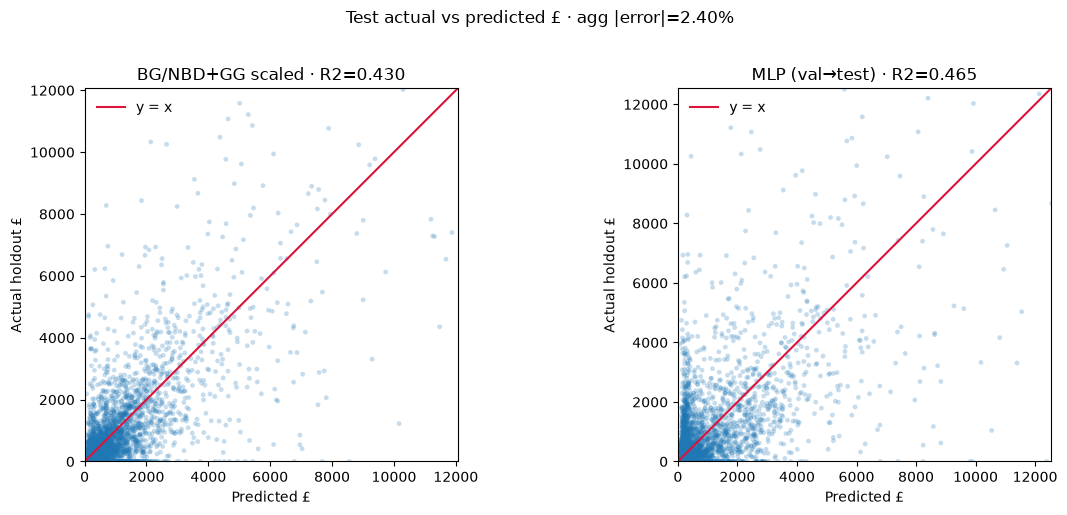

In [14]:
summary = s_test
t_horizon = hw_test

eval_df = summary[
    ["expected_clv", "expected_clv_raw", "expected_purchases", "actual_holdout_revenue", "frequency_holdout"]
].dropna().copy()

mae = mean_absolute_error(eval_df["actual_holdout_revenue"], eval_df["expected_clv"])
r2 = r2_score(eval_df["actual_holdout_revenue"], eval_df["expected_clv"])
spearman = spearmanr(eval_df["expected_clv"], eval_df["actual_holdout_revenue"]).correlation
sp_purch = spearmanr(eval_df["expected_purchases"], eval_df["frequency_holdout"]).correlation

n = len(eval_df)
k = max(int(n * 0.10), 1)
total_rev = eval_df["actual_holdout_revenue"].sum()
capture = eval_df.nlargest(k, "expected_clv")["actual_holdout_revenue"].sum() / total_rev
ideal = eval_df.nlargest(k, "actual_holdout_revenue")["actual_holdout_revenue"].sum() / total_rev

print(f"TEST £ · {t_horizon}w — aggregate |error|: {agg_error:.2%} (limit {AGG_ERROR_MAX:.0%})")
print(f"  Spearman revenue: {spearman:.3f} · purchases: {sp_purch:.3f}")
print(f"  Top-decile capture: {capture:.1%} (ideal {ideal:.1%})")
print(f"  MAE: {mae:.2f} · R2: {r2:.3f}")

# MLP foil: train on VAL labels only, score on TEST
rfm_val = s_val[
    ["frequency_cal", "recency_cal", "T_cal", "monetary_value_cal", "actual_holdout_revenue"]
].copy()
rfm_test = summary[
    ["frequency_cal", "recency_cal", "T_cal", "monetary_value_cal", "actual_holdout_revenue"]
].copy()
X_tr = rfm_val[["frequency_cal", "recency_cal", "T_cal", "monetary_value_cal"]]
y_tr = rfm_val["actual_holdout_revenue"]
X_te = rfm_test[["frequency_cal", "recency_cal", "T_cal", "monetary_value_cal"]]
y_te = rfm_test["actual_holdout_revenue"]
mlp_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE)),
])
mlp_pipe.fit(X_tr, y_tr)
mlp_pred = mlp_pipe.predict(X_te)
mlp_sp = spearmanr(mlp_pred, y_te).correlation
mlp_r2 = r2_score(y_te, mlp_pred)
mlp_mae = mean_absolute_error(y_te, mlp_pred)
print(f"MLP baseline (train=VAL, test=TEST) — Spearman: {mlp_sp:.3f} · R2: {mlp_r2:.3f} · MAE: {mlp_mae:.2f}")
best_name = (
    "BG/NBD+Gamma-Gamma"
    if (float(spearman) if spearman == spearman else -1) >= (float(mlp_sp) if mlp_sp == mlp_sp else -1)
    else "MLP"
)
print(f"Selected on ranking: {best_name}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, pred, actual, title in (
    (axes[0], eval_df["expected_clv"], eval_df["actual_holdout_revenue"], f"BG/NBD+GG scaled · R2={r2:.3f}"),
    (axes[1], pd.Series(mlp_pred), y_te.reset_index(drop=True), f"MLP (val→test) · R2={mlp_r2:.3f}"),
):
    lim = float(np.nanpercentile(np.concatenate([np.asarray(pred), np.asarray(actual)]), 99))
    lim = max(lim, 1.0)
    ax.scatter(pred, actual, alpha=0.25, s=12, edgecolors="none")
    ax.plot([0, lim], [0, lim], color="crimson", lw=1.5, label="y = x")
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)
    ax.set_xlabel("Predicted £")
    ax.set_ylabel("Actual holdout £")
    ax.set_title(title)
    ax.legend(frameon=False)
    ax.set_aspect("equal", adjustable="box")
fig.suptitle(f"Test actual vs predicted £ · agg |error|={agg_error:.2%}", y=1.02)
plt.tight_layout()
plt.show()


#### Assessment — CLV protocol

Gate + leakage define ship / no-ship. Ranking (Spearman, top-decile capture) decides whether equity concentrates real spend. Customer-level R² stays modest in heavy-tailed retail — secondary.


## 10 · Segments (value × activity)

Map CLV × expected purchases to actions (VIP retention, win-back, upsell, nurture, minimize) — how BTYD scores enter marketing decisions.


,segment,n_customers,mean_exp_purch,mean_p_alive,mean_clv,total_clv,total_holdout_rev
3,VIP retention,1395,4.61,0.96,2041.15,2847399.94,4493712.74
1,Minimize spend,2165,0.84,0.96,197.72,428061.33,468771.22
2,Upsell,805,2.25,0.96,426.19,343086.14,367417.17
4,Win-back,146,1.25,0.92,951.35,138896.78,118358.53
0,Low-cost nurture,111,1.98,0.93,156.82,17406.68,23815.54


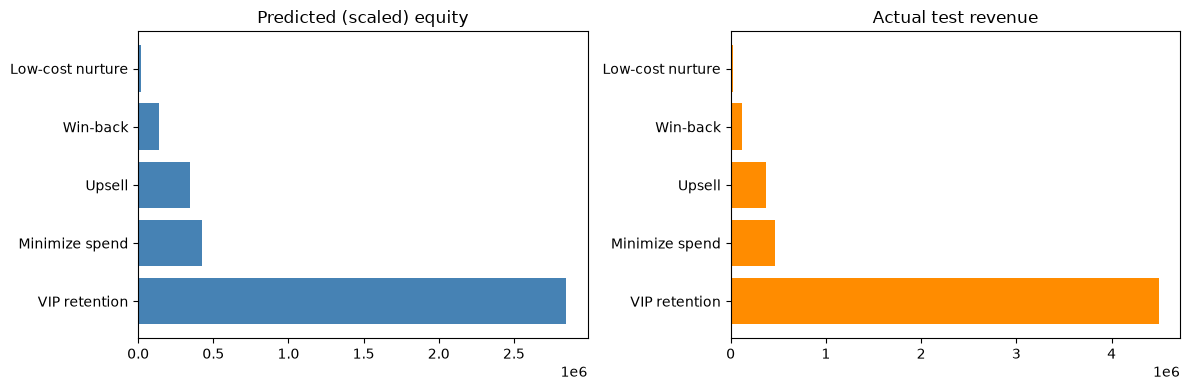

In [15]:
seg_clv_col = "expected_clv"
for h in (52, 26, 13, 4, t_horizon):
    c = f"expected_clv_{h}w"
    if c in summary.columns:
        seg_clv_col = c
        break

summary = assign_segments(summary, seg_clv_col)
seg_summary = (
    summary.groupby("segment", as_index=False)
    .agg(
        n_customers=("expected_purchases", "size"),
        mean_exp_purch=("expected_purchases", "mean"),
        mean_p_alive=("p_alive", "mean"),
        mean_clv=(seg_clv_col, "mean"),
        total_clv=(seg_clv_col, "sum"),
        total_holdout_rev=("actual_holdout_revenue", "sum"),
    )
    .sort_values("total_holdout_rev", ascending=False)
)
display(seg_summary.round(2))
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].barh(seg_summary["segment"], seg_summary["total_clv"], color="steelblue")
axes[0].set_title("Predicted (scaled) equity")
axes[1].barh(seg_summary["segment"], seg_summary["total_holdout_rev"], color="darkorange")
axes[1].set_title("Actual test revenue")
plt.tight_layout()
plt.show()


#### Assessment — segments

Predicted equity should align directionally with realized test £. Prefer retention on high-CLV / high-activity; win-back where value is high but expected purchases are soft.


## 11 · Decision scenarios (illustrative)

Portfolio sensitivity only — not causal uplift.


,scenario,delta
0,+5% value on top 10% CLV,137476.0
1,+0.2 purchases on Upsell,51279.0
2,+10% AOV (scale CLV),534097.0


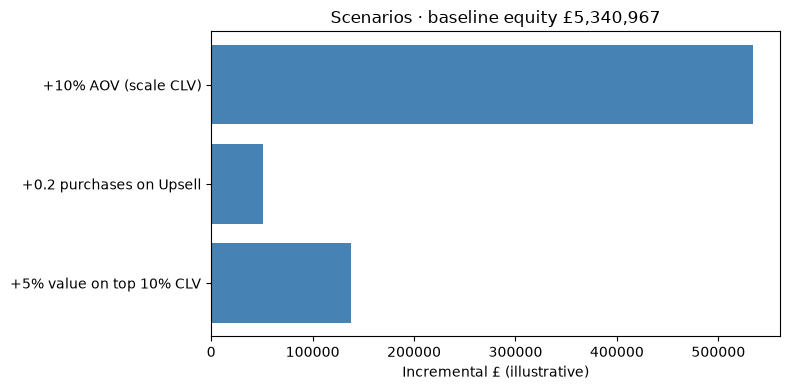

In [16]:
equity0 = float(summary["expected_clv"].sum())
scenarios = []
top_n = max(int(len(summary) * 0.10), 1)
top_ids = summary.nlargest(top_n, "expected_clv").index
s1 = summary["expected_clv"].copy()
s1.loc[top_ids] *= 1.05
scenarios.append({"scenario": "+5% value on top 10% CLV", "delta": float(s1.sum() - equity0)})
upsell = summary["segment"] == "Upsell"
s2 = summary["expected_clv"].copy()
s2.loc[upsell] = s2.loc[upsell] + 0.2 * float(summary["expected_avg_spend"].median())
scenarios.append({"scenario": "+0.2 purchases on Upsell", "delta": float(s2.sum() - equity0)})
scenarios.append({"scenario": "+10% AOV (scale CLV)", "delta": float(equity0 * 0.10)})
scen_df = pd.DataFrame(scenarios)
display(scen_df.round(0))
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(scen_df["scenario"], scen_df["delta"], color="steelblue")
ax.set_xlabel("Incremental £ (illustrative)")
ax.set_title(f"Scenarios · baseline equity £{equity0:,.0f}")
plt.tight_layout()
plt.show()


#### Assessment — scenarios

Use to size conversations (protect top CLV decile vs broad AOV). Validate live programs with a proper test design.


## 12 · Artifacts

Persist only after the £ gate. Downstream must read `accepted` + leakage audit. Model is **stationary** weekly BG/NBD + Gamma-Gamma (no seasonal overlay).


In [17]:
assert_accepted(result)

bgf.save_model(str(MODELS / "01_clv_bgf"))
ggf.save_model(str(MODELS / "01_clv_ggf"))
save_artifact("01_clv_best.joblib", {
    "selected": best_name,
    "model": "BetaGeoFitter+GammaGamma",
    "purchase_model": "BG/NBD",
    "accepted": True,
    "agg_error_max": AGG_ERROR_MAX,
    "agg_error_test": float(agg_error),
    "orders_agg_error_test": float(orders_agg_error),
    "fit_frac": FIT_FRAC,
    "val_frac": VAL_FRAC,
    "val_scale": float(scale),
    "fit_end": str(fit_end.date()),
    "val_end": str(val_end.date()),
    "obs_end": str(max_d.date()),
    "horizon_weeks": t_horizon,
    "metrics": {
        "spearman": float(spearman) if spearman == spearman else None,
        "spearman_purchases": float(sp_purch) if sp_purch == sp_purch else None,
        "top_decile_capture": float(capture),
        "ideal_top_decile": float(ideal),
        "mae": float(mae),
        "r2": float(r2),
        "agg_error_test": float(agg_error),
        "orders_agg_error_test": float(orders_agg_error),
    },
    "clv_formula": "E[purchases]_BG/NBD * E[spend]_GG * val_revenue_scale",
    "seasonality_overlays": False,
    "discounting": False,
    "stepwise_notebook": True,
    "grain": "customer",
    "mlp_pipeline": mlp_pipe,
    "leakage_audit": leak,
})
scores_path = MODELS / "01_clv_customer_scores.parquet"
summary.reset_index().to_parquet(scores_path, index=False)
print(f"Saved → {scores_path.relative_to(PROJECT_ROOT)}")
print(
    f"ACCEPTED · stationary BG/NBD+GG · £ |error|={agg_error:.2%} · "
    f"purchase |error|={orders_agg_error:.1%} (informational)"
)


Saved → models\01_clv_best.joblib
Saved → models\01_clv_customer_scores.parquet
ACCEPTED · stationary BG/NBD+GG · £ |error|=2.40% · purchase |error|=6.9% (informational)


#### Bottom line

Full BTYD chain (stationary Hardie path):

1. Data → 2. Explore → 3. Protocol → 4. RFM → 5–6. Val BG/NBD + GG (scale) → 7–8. Test BG/NBD + GG → 9. Scaled CLV + gate → 10–11. Uses → 12. Artifacts.

**Ship:** stationary BG/NBD + GG when the £ gate passes.  
**Do not use for:** week-level seasonal demand planning; discounted NPV CLV (not computed here).
